=== MODÈLE DE DÉTECTION D'ANOMALIES - VERSION LÉGÈRE (sans TensorFlow) ===

Utilisation de 5,000 fenêtres
Shape des données : (5000, 2280)

Entraînement du modèle Isolation Forest...
Nombre d'anomalies détectées : 250 / 5000
Pourcentage d'anomalies : 5.00%


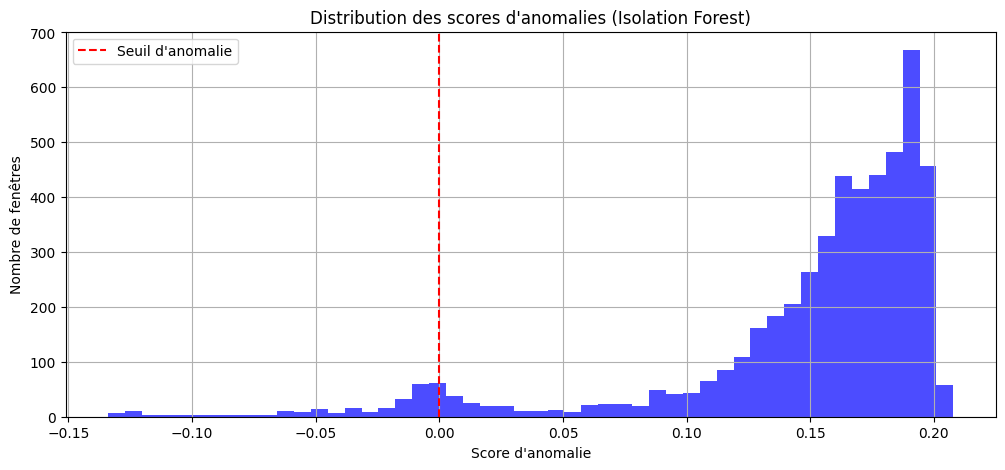


Modèle Isolation Forest sauvegardé avec succès !
Fichiers créés :
   - models/isolation_forest_model.pkl
   - models/scaler.pkl

Ce modèle est léger et ne devrait pas faire planter le kernel.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

print("=== MODÈLE DE DÉTECTION D'ANOMALIES - VERSION LÉGÈRE (sans TensorFlow) ===\n")

# ==================== CHARGEMENT DES DONNÉES ====================
WINDOWS_PATH = 'data/processed/windows/'

X_windows = np.load(os.path.join(WINDOWS_PATH, 'X_windows.npy'))

# On prend un nombre raisonnable de fenêtres
MAX_SAMPLES = 5000
X_windows = X_windows[:MAX_SAMPLES]

print(f"Utilisation de {X_windows.shape[0]:,} fenêtres")

# Aplatir les fenêtres (chaque fenêtre devient une ligne)
X_flat = X_windows.reshape(X_windows.shape[0], -1)

print(f"Shape des données : {X_flat.shape}")

# ==================== NORMALISATION ====================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

# ==================== MODÈLE : Isolation Forest (très léger) ====================
print("\nEntraînement du modèle Isolation Forest...")

model = IsolationForest(
    n_estimators=100,
    contamination=0.05,   # On suppose 5% d'anomalies
    random_state=42
)

model.fit(X_scaled)

# Prédiction (-1 = anomalie, 1 = normal)
predictions = model.predict(X_scaled)
anomaly_scores = model.decision_function(X_scaled)

print(f"Nombre d'anomalies détectées : {(predictions == -1).sum()} / {len(predictions)}")
print(f"Pourcentage d'anomalies : {(predictions == -1).mean()*100:.2f}%")

# ==================== VISUALISATION ====================
plt.figure(figsize=(12, 5))
plt.hist(anomaly_scores, bins=50, color='blue', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Seuil d\'anomalie')
plt.title('Distribution des scores d\'anomalies (Isolation Forest)')
plt.xlabel('Score d\'anomalie')
plt.ylabel('Nombre de fenêtres')
plt.legend()
plt.grid(True)
plt.show()

# Sauvegarde du modèle
import joblib
os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/isolation_forest_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("\nModèle Isolation Forest sauvegardé avec succès !")
print("Fichiers créés :")
print("   - models/isolation_forest_model.pkl")
print("   - models/scaler.pkl")

print("\nCe modèle est léger et ne devrait pas faire planter le kernel.")

In [2]:
import joblib
import os

# Créer le dossier models s'il n'existe pas
os.makedirs('models', exist_ok=True)

# Sauvegarder le modèle et le scaler
joblib.dump(model, 'models/isolation_forest_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Modèle et scaler sauvegardés avec succès !")
print("Fichiers créés :")
print("   - models/isolation_forest_model.pkl")
print("   - models/scaler.pkl")

✅ Modèle et scaler sauvegardés avec succès !
Fichiers créés :
   - models/isolation_forest_model.pkl
   - models/scaler.pkl
